# exp13: LSTM dengan grid lebar yang diperluas

Notebook **pelapor**: membaca berkas hasil yang sudah ada, tidak melatih model,
tidak menulis ke `results/`, tidak mengimpor `src/experiments` maupun `tools`.

## 1. Ringkasan

**Pertanyaan yang dijawab.** RQ1, kelayakan pembanding. Pada exp12, lebar LSTM yang dipilih
pada data validasi jatuh **di tepi** grid {64, 128, 256} pada **23 dari 32 konfigurasi**
(64 pada 12 konfigurasi, 256 pada 11). Subbab 4.6.2 mencantumkan hal ini sebagai
keterbatasan perbandingan, karena lebar optimal yang berada di luar grid akan merugikan LSTM.

exp13 menutup keterbatasan itu dengan menambah satu lebar di bawah dan satu di atas grid
exp12, sehingga menjadi **{32, 64, 128, 256, 512}**.

**Ramalan pra-registrasi** (`PREREG_exp10_exp13_exp14.md` bagian 4, di-*commit* sebelum
skrip dijalankan sekali pun):

| | Bunyi ramalan | Hasil |
|---|---|---|
| **P4a** | Perubahan gabungan RMSE uji LSTM terhadap exp12 dalam ±2% | **Terbukti** (−0,15%) |
| **P4b** | AR-LRX tidak lebih buruk daripada LSTM grid lebar lebih dari 1% | **Terbukti** (−0,65% / −1,38%) |

**Dipakai di mana.**

| Naskah | Bagian |
|---|---|
| Disertasi | Subbab 4.6.2, **Tabel 4.11** baris "LSTM, grid {32, …, 512} (exp13)" |
| Paper IJIES | **tidak dipakai**, karena dijalankan setelah naskah ronde 2 dikirim |

## 2. Lingkungan

In [1]:
# Notebook pelapor: HANYA MEMBACA.
# Tidak melatih model, tidak mengimpor src/experiments atau tools (agar TensorFlow
# tidak ikut termuat), dan tidak pernah menulis ke results/, data/ atau raw/.
%matplotlib inline
from pathlib import Path
import ast, json, hashlib, datetime, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def cari_root(p: Path) -> Path:
    for c in [p, *p.parents]:
        if (c / "results").is_dir() and (c / "src" / "experiments").is_dir():
            return c
    raise RuntimeError("root repositori tidak ditemukan dari " + str(p))


ROOT = cari_root(Path.cwd().resolve())
RES = ROOT / "results"

pd.set_option("display.width", 210)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 95)
pd.set_option("display.max_rows", 200)

print("Root repositori :", ROOT)
print("Folder hasil    :", RES.relative_to(ROOT),
      f"({sum(1 for f in RES.rglob('*') if f.is_file())} berkas)")
print("Dijalankan      :", datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))


def idn(x, d=2, tanda=False):
    """Format angka gaya Indonesia (koma desimal, titik ribuan)."""
    s = f"{x:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")
    if tanda and x > 0:
        s = "+" + s
    return s.replace("-", "\u2212")


def baca(nama, **kw):
    """Baca satu berkas di results/ sebagai DataFrame. Read-only."""
    f = RES / nama
    if not f.exists():
        raise FileNotFoundError(f"{nama} tidak ada di results/")
    return pd.read_csv(f, **kw)


def potongan(relpath, nama=None, awal=None, akhir=None):
    """Tampilkan potongan kode dengan membaca berkas sebagai TEKS.

    Memakai ``ast`` untuk menemukan batas fungsi/konstanta, sehingga modul
    eksperimen tidak perlu diimpor.
    """
    f = ROOT / relpath
    teks = f.read_text(encoding="utf-8")
    baris = teks.splitlines()
    if nama is not None:
        pohon = ast.parse(teks)
        ketemu = False
        for n in ast.walk(pohon):
            if isinstance(n, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)) and n.name == nama:
                awal, akhir, ketemu = n.lineno, n.end_lineno, True
                break
            if isinstance(n, ast.Assign) and any(getattr(t, "id", None) == nama for t in n.targets):
                awal, akhir, ketemu = n.lineno, n.end_lineno, True
                break
        if not ketemu:
            raise KeyError(f"'{nama}' tidak ditemukan di {relpath}")
    awal = awal or 1
    akhir = akhir or len(baris)
    lebar = len(str(akhir))
    print(f"--- {relpath}:{awal}-{akhir} " + "-" * max(0, 74 - len(relpath)))
    for i in range(awal, akhir + 1):
        print(f"{str(i).rjust(lebar)} | {baris[i - 1]}")


def git(*args):
    """Jalankan perintah git read-only di root repositori."""
    try:
        r = subprocess.run(["git", *args], cwd=ROOT, capture_output=True, text=True, timeout=30)
        return r.stdout.strip() if r.returncode == 0 else ""
    except Exception:
        return ""


def asal(nama_meta=None, berkas_hasil=None, skrip=None, log=None):
    """Cetak asal-usul: meta.json, commit, dan log run bila ada."""
    if nama_meta:
        f = RES / nama_meta
        if f.exists():
            print("meta.json " + "-" * 60)
            print(json.dumps(json.loads(f.read_text(encoding="utf-8")), indent=2, ensure_ascii=False))
            print()
    for label, path in [("berkas hasil", berkas_hasil), ("skrip", skrip)]:
        if path:
            print(f"commit terakhir yang menyentuh {label} ({path})")
            print("  " + (git("log", "-1", "--date=short", "--format=%h  %ad  %s", "--", path) or "(tidak terbaca)"))
    if log:
        f = RES / "logs" / log
        print()
        if f.exists():
            print(f"results/logs/{log}  ({f.stat().st_size} bytes, "
                  f"ditulis {datetime.datetime.fromtimestamp(f.stat().st_mtime):%Y-%m-%d %H:%M})")
        else:
            print(f"results/logs/{log} tidak ada di klon ini (berkas *.log diabaikan git).")

Root repositori : I:\Shared drives\Riset S3\Experiment S3 Code\antgravity_riset\AR-LRX_hybrid-forecasting


Folder hasil    : results (179 berkas)
Dijalankan      : 2026-09-29 19:30


In [2]:
# Pembanding angka CSV terhadap angka yang tercetak di disertasi.
# Tidak ada angka yang dibetulkan di sini; ketidakcocokan hanya dilaporkan.
_cek = []


def cek(butir, nilai_csv, nilai_naskah, tol=0.005, d=4, rujukan=""):
    beda = abs(float(nilai_csv) - float(nilai_naskah))
    ok = beda <= tol
    _cek.append({
        "Butir": butir,
        "Rujukan naskah": rujukan,
        "Dari CSV": round(float(nilai_csv), d),
        "Di disertasi": float(nilai_naskah),
        "|selisih|": round(beda, 6),
        "Status": "COCOK" if ok else "TIDAK COCOK",
    })
    return ok


def laporan_cek():
    t = pd.DataFrame(_cek)
    n_ok = int((t.Status == "COCOK").sum())
    display(t)
    print()
    print(f"RINGKASAN: {n_ok} dari {len(t)} angka COCOK dengan naskah disertasi.")
    buruk = t[t.Status == "TIDAK COCOK"]
    if len(buruk):
        print()
        print("!" * 78)
        print("ADA ANGKA YANG TIDAK COCOK. Tidak dibetulkan di notebook ini.")
        print("Laporkan butir berikut sebelum notebook dipakai sebagai lampiran:")
        for _, r in buruk.iterrows():
            print(f"  - {r.Butir} ({r['Rujukan naskah']}): "
                  f"CSV {r['Dari CSV']} vs naskah {r['Di disertasi']}")
        print("!" * 78)
    else:
        print("Tidak ada selisih di luar toleransi pembulatan.")
    return t

## 3. Desain eksperimen

**Seluruh rancangan identik dengan exp12, kecuali gridnya.** Hanya bagian itu yang berubah:

In [3]:
potongan("tools/exp13_pharma_lstm_wide.py", nama="GRID_LSTM_WIDE")

--- tools/exp13_pharma_lstm_wide.py:52-52 -------------------------------------------
52 | GRID_LSTM_WIDE = {"units": [32, 64, 128, 256, 512], "learning_rate": [0.001]}


**Model yang dijalankan.** LSTM grid lebar, ditambah `S1 [linear]` dan `AR-LRX [linear]`
yang **dihitung ulang** dengan kode analisis exp12 yang tidak diubah, agar uji
Diebold–Mariano berpasangan memakai prediksi dari satu run yang sama.

In [4]:
potongan("tools/exp13_pharma_lstm_wide.py", nama="run")

--- tools/exp13_pharma_lstm_wide.py:56-75 -------------------------------------------
56 | def run(quick: bool):
57 |     from src.experiments import baselines as B
58 |     P.set_global_seed()
59 |     lstm_fp = B.make_keras_fp_v2("lstm", batch_size=E12.LSTM_BATCH)
60 |     grid = {"units": [32, 512], "learning_rate": [0.001]} if quick else GRID_LSTM_WIDE
61 |     cats = E12.CATEGORIES[:2] if quick else E12.CATEGORIES
62 |     rows, data = [], {}
63 |     t0 = time.time()
64 |     for gran, path, sp in E12.GRANS:
65 |         raw = pd.read_csv(path)
66 |         for cat in cats:
67 |             for fs in P.FEATURE_SETS:
68 |                 d = P.build_pharma_dataset(raw, cat, fs, seasonal_period=sp, lag_rule="pacf_train")
69 |                 data[(gran, cat, fs)] = d
70 |                 add = lambda r: rows.append({**r, "granularity": gran})
71 |                 add(A.run_stage1_only("S1 [linear]", d, "linear"))
72 |                 add(A.run_arlrx("AR-LRX [linear]", d, "linear", 

**Perbandingan langsung dengan exp12.** Baris LSTM exp12 dibaca dari
`results/exp12_pharma_baselines.csv` dan dilaporkan berdampingan, meliputi perubahan RMSE uji
dan lebar yang terpilih pada setiap konfigurasi:

In [5]:
potongan("tools/exp13_pharma_lstm_wide.py", nama="compare_exp12")

--- tools/exp13_pharma_lstm_wide.py:78-92 -------------------------------------------
78 | def compare_exp12(rows) -> pd.DataFrame:
79 |     f = P.RESULTS_DIR / "exp12_pharma_baselines.csv"
80 |     new = pd.DataFrame([r for r in rows if r["model"] == MODEL])
81 |     new["units_new"] = new.params.map(lambda s: eval(s)["units"] if isinstance(s, str) else np.nan)
82 |     key = ["granularity", "category", "feature_set"]
83 |     if not f.exists():
84 |         return new[key + ["test_RMSE", "units_new"]]
85 |     old = pd.read_csv(f)
86 |     old = old[old.model == "LSTM"][key + ["test_RMSE", "params"]].rename(
87 |         columns={"test_RMSE": "test_RMSE_exp12", "params": "params_exp12"})
88 |     old["units_exp12"] = old.params_exp12.map(lambda s: eval(s)["units"])
89 |     out = new[key + ["test_RMSE", "units_new", "n_lags"]].merge(old, on=key, how="left")
90 |     out["change_pct"] = 100 * (out.test_RMSE / out.test_RMSE_exp12 - 1)
91 |     out["new_width_selected"] = out.units_new.

**Kontrak.** C1–C8 tidak diubah. Batch 32, *learning rate* 0,001, seleksi pada RMSE validasi
(C3), refit pada latih+validasi (C6).

## 4. Asal-usul hasil

In [6]:
RUN_EXPERIMENT = False

PERINTAH = [
    "python tools/exp13_pharma_lstm_wide.py",
]

if RUN_EXPERIMENT:
    for c in PERINTAH:
        print(">>", c)
        r = subprocess.run(c, shell=True, cwd=ROOT)
        print("   kode keluar:", r.returncode)
else:
    print("RUN_EXPERIMENT = False - eksperimen TIDAK dijalankan ulang.")
    print()
    print("Perintah asli yang menghasilkan berkas di results/:")
    for c in PERINTAH:
        print("   ", c)
    print()
    print('Langkah kedua pada tools/run_exp10_13_14.bat. Selesai sekitar pukul 09:02 pada 26 September 2026. Membutuhkan TensorFlow.')

RUN_EXPERIMENT = False - eksperimen TIDAK dijalankan ulang.

Perintah asli yang menghasilkan berkas di results/:
    python tools/exp13_pharma_lstm_wide.py

Langkah kedua pada tools/run_exp10_13_14.bat. Selesai sekitar pukul 09:02 pada 26 September 2026. Membutuhkan TensorFlow.


In [7]:
asal(nama_meta="exp13_pharma_lstm_wide.meta.json", berkas_hasil="results/exp13_pharma_lstm_wide.csv", skrip="tools/exp13_pharma_lstm_wide.py", log="exp13.log")

meta.json ------------------------------------------------------------
{
  "experiment": "exp13_pharma_lstm_wide",
  "n_rows": 96,
  "protocol": {
    "split_ratios": [
      0.7,
      0.15,
      0.15
    ],
    "tuning": "validation-only, refit on train+val",
    "feature_sets": [
      "A_lag1",
      "B_rich"
    ]
  },
  "environment": {
    "python": "3.10.11",
    "platform": "Windows-10-10.0.22621-SP0",
    "numpy": "2.2.6",
    "pandas": "2.3.3",
    "seed": "42",
    "sklearn": "1.7.2",
    "xgboost": "3.2.0",
    "statsmodels": "0.14.6"
  }
}

commit terakhir yang menyentuh berkas hasil (results/exp13_pharma_lstm_wide.csv)


  3a642df  2026-09-26  Results of pre-registered exp10, exp13, exp14
commit terakhir yang menyentuh skrip (tools/exp13_pharma_lstm_wide.py)


  b913709  2026-09-26  Pre-register exp10, exp13, exp14: design and predictions P4-P9

results/logs/exp13.log  (4639 bytes, ditulis 2026-09-26 09:02)


## 5. Hasil

In [8]:
e13 = baca("exp13_pharma_lstm_wide_summary.csv")
v13 = baca("exp13_pharma_lstm_wide_vs_exp12.csv")
raw13 = baca("exp13_pharma_lstm_wide.csv")

d13 = e13[e13.scope == "distinct"].set_index(["reference", "granularity"])
print("AR-LRX terhadap LSTM grid lebar, 20 konfigurasi berbeda:")
display(e13[e13.scope == "distinct"].drop(columns="scope").round(3).reset_index(drop=True))
print()
r = v13.test_RMSE / v13.test_RMSE_exp12
pooled = 100 * (np.exp(np.log(r).mean()) - 1)
print(f"Perubahan RMSE uji LSTM secara gabungan terhadap exp12 : {idn(pooled, 2, True)}%")
print(f"Konfigurasi yang memilih lebar baru (32 atau 512)      : "
      f"{int(v13.new_width_selected.sum())} dari {len(v13)}")
print()
print("Sebaran lebar yang terpilih pada grid baru:")
print(v13.units_new.value_counts().sort_index().to_string())
print()
print("Sebaran lebar yang terpilih pada grid exp12 {64, 128, 256}:")
print(v13.units_exp12.value_counts().sort_index().to_string())

AR-LRX terhadap LSTM grid lebar, 20 konfigurasi berbeda:


,reference,granularity,n,arlrx_wins,sig_wins_bh,sig_losses_bh,pooled_pct
0,LSTM (wide grid),daily,10,4,4,0,-0.649
1,LSTM (wide grid),weekly,10,6,1,0,-1.376
2,S1 [linear],daily,10,2,0,0,0.180
3,S1 [linear],weekly,10,2,0,0,0.384



Perubahan RMSE uji LSTM secara gabungan terhadap exp12 : −0,15%
Konfigurasi yang memilih lebar baru (32 atau 512)      : 20 dari 32

Sebaran lebar yang terpilih pada grid baru:
units_new
32      7
64      5
128     4
256     3
512    13

Sebaran lebar yang terpilih pada grid exp12 {64, 128, 256}:
units_exp12
64     12
128     9
256    11


### 5.1 Perbandingan per konfigurasi terhadap exp12

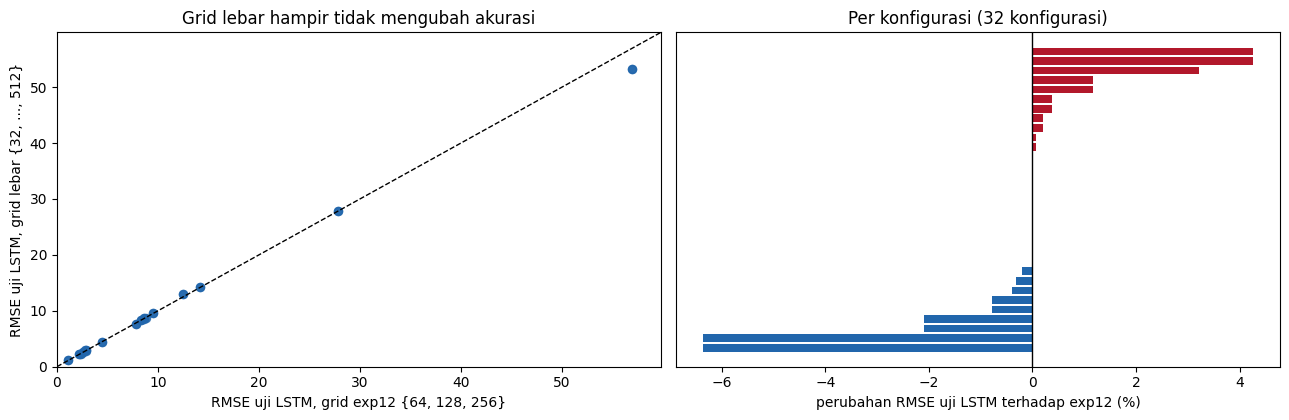

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

axes[0].scatter(v13.test_RMSE_exp12, v13.test_RMSE, s=34, color="#2166ac", alpha=0.8)
lim = [0, max(v13.test_RMSE.max(), v13.test_RMSE_exp12.max()) * 1.05]
axes[0].plot(lim, lim, "k--", lw=1)
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("RMSE uji LSTM, grid exp12 {64, 128, 256}")
axes[0].set_ylabel("RMSE uji LSTM, grid lebar {32, ..., 512}")
axes[0].set_title("Grid lebar hampir tidak mengubah akurasi")

s = v13.sort_values("change_pct")
warna = ["#b2182b" if v > 0 else "#2166ac" for v in s.change_pct]
axes[1].barh(range(len(s)), s.change_pct, color=warna)
axes[1].axvline(0, color="black", lw=1)
axes[1].set_yticks([])
axes[1].set_xlabel("perubahan RMSE uji LSTM terhadap exp12 (%)")
axes[1].set_title("Per konfigurasi (32 konfigurasi)")
fig.tight_layout(); plt.show()

## 6. Pengujian ulang ramalan P4

In [10]:
print("P4a. 'Perubahan gabungan RMSE uji LSTM terhadap exp12 berada dalam +/-2%")
print("      (seluruh 32 konfigurasi).'")
print(f"      teramati: {idn(pooled, 2, True)}%  ->  "
      f"{'terpenuhi' if abs(pooled) <= 2 else 'TIDAK TERPENUHI'}")
print()
print("P4b. 'AR-LRX [linear] tidak lebih buruk daripada LSTM grid lebar lebih dari 1%")
print("      secara gabungan, pada data harian maupun mingguan (pooled_pct <= +1,0).'")
for g in ["daily", "weekly"]:
    v = d13.loc[("LSTM (wide grid)", g)].pooled_pct
    print(f"      {g:7s}: pooled_pct = {idn(v, 2, True)}%  ->  "
          f"{'terpenuhi' if v <= 1.0 else 'TIDAK TERPENUHI'}")
print()
print("=" * 78)
print("KESIMPULAN: P4a dan P4b TERBUKTI.")
print("Batas grid tidak membatasi LSTM pada data ini: lebar baru terpilih pada")
print(f"{int(v13.new_width_selected.sum())} dari 32 konfigurasi, tetapi hampir tanpa perubahan akurasi.")

P4a. 'Perubahan gabungan RMSE uji LSTM terhadap exp12 berada dalam +/-2%
      (seluruh 32 konfigurasi).'
      teramati: −0,15%  ->  terpenuhi

P4b. 'AR-LRX [linear] tidak lebih buruk daripada LSTM grid lebar lebih dari 1%
      secara gabungan, pada data harian maupun mingguan (pooled_pct <= +1,0).'
      daily  : pooled_pct = −0,65%  ->  terpenuhi
      weekly : pooled_pct = −1,38%  ->  terpenuhi

KESIMPULAN: P4a dan P4b TERBUKTI.
Batas grid tidak membatasi LSTM pada data ini: lebar baru terpilih pada
20 dari 32 konfigurasi, tetapi hampir tanpa perubahan akurasi.


## 7. Cek kecocokan dengan angka disertasi

In [11]:
cek("Tabel 4.11 LSTM grid lebar harian: AR-LRX menang",
    d13.loc[("LSTM (wide grid)", "daily")].arlrx_wins, 4, tol=0, rujukan="Tabel 4.11")
cek("Tabel 4.11 LSTM grid lebar harian: menang signifikan",
    d13.loc[("LSTM (wide grid)", "daily")].sig_wins_bh, 4, tol=0, rujukan="Subbab 4.6.2")
cek("Tabel 4.11 LSTM grid lebar harian: gabungan (%)",
    d13.loc[("LSTM (wide grid)", "daily")].pooled_pct, -0.65, tol=0.005, rujukan="Subbab 4.6.2")
cek("Tabel 4.11 LSTM grid lebar mingguan: gabungan (%)",
    d13.loc[("LSTM (wide grid)", "weekly")].pooled_pct, -1.38, tol=0.005, rujukan="Subbab 4.6.2")
cek("Subbab 4.6.2: perubahan gabungan RMSE LSTM terhadap exp12 (%)", pooled, -0.15,
    tol=0.005, rujukan="Subbab 4.6.2 / P4a")
cek("Subbab 4.6.2: konfigurasi yang memilih lebar 32 atau 512",
    int(v13.new_width_selected.sum()), 20, tol=0, rujukan="Subbab 4.6.2")
cek("Pra-registrasi: lebar terpilih di tepi grid exp12 (23 dari 32)",
    int(v13.units_exp12.isin([64, 256]).sum()), 23, tol=0, rujukan="PREREG bagian 1")
cek("Jumlah konfigurasi seluruhnya", len(v13), 32, tol=0, rujukan="Subbab 4.6.2")

# AR-LRX dan S1 harus identik dengan exp12 (kode analisis yang sama)
e12d = baca("exp12_pharma_baselines_summary.csv")
e12d = e12d[e12d.scope == "distinct"].set_index(["reference", "granularity"])
for g in ["daily", "weekly"]:
    cek(f"S1 [linear] {g}: exp13 sama dengan exp12",
        d13.loc[("S1 [linear]", g)].pooled_pct, e12d.loc[("S1 [linear]", g)].pooled_pct,
        tol=1e-9, rujukan="catatan Tabel 4.11")

hasil_cek = laporan_cek()

,Butir,Rujukan naskah,Dari CSV,Di disertasi,|selisih|,Status
0,Tabel 4.11 LSTM grid lebar harian: AR-LRX menang,Tabel 4.11,4.0000,4.000000,0.000000,COCOK
1,Tabel 4.11 LSTM grid lebar harian: menang signifikan,Subbab 4.6.2,4.0000,4.000000,0.000000,COCOK
2,Tabel 4.11 LSTM grid lebar harian: gabungan (%),Subbab 4.6.2,-0.6495,-0.650000,0.000521,COCOK
3,Tabel 4.11 LSTM grid lebar mingguan: gabungan (%),Subbab 4.6.2,-1.3757,-1.380000,0.004340,COCOK
4,Subbab 4.6.2: perubahan gabungan RMSE LSTM terhadap exp12 (%),Subbab 4.6.2 / P4a,-0.1481,-0.150000,0.001897,COCOK
5,Subbab 4.6.2: konfigurasi yang memilih lebar 32 atau 512,Subbab 4.6.2,20.0000,20.000000,0.000000,COCOK
6,Pra-registrasi: lebar terpilih di tepi grid exp12 (23 dari 32),PREREG bagian 1,23.0000,23.000000,0.000000,COCOK
7,Jumlah konfigurasi seluruhnya,Subbab 4.6.2,32.0000,32.000000,0.000000,COCOK
8,S1 [linear] daily: exp13 sama dengan exp12,catatan Tabel 4.11,0.1796,0.179629,0.000000,COCOK
9,S1 [linear] weekly: exp13 sama dengan exp12,catatan Tabel 4.11,0.3835,0.383523,0.000000,COCOK



RINGKASAN: 10 dari 10 angka COCOK dengan naskah disertasi.
Tidak ada selisih di luar toleransi pembulatan.


## 8. Interpretasi dan keterbatasan

**Batas grid tidak membatasi LSTM pada data ini.** Lebar baru, yaitu 32 atau 512, terpilih
pada 20 dari 32 konfigurasi, sehingga pencarian memang bergerak ke wilayah baru. Akurasinya
hampir tidak berubah, karena RMSE uji LSTM hanya bergeser −0,15% secara gabungan.

**Keterbatasan yang dicatat disertasi sudah ditutup.** Subbab 4.6.2 mencatat bahwa lebar LSTM
pada exp12 sering berada di batas grid, dan exp13 dijalankan untuk menguji apakah hal itu
merugikan LSTM. Hasilnya menunjukkan bahwa melebarkan grid menggeser lebar yang terpilih
tanpa memperbaiki akurasi.

**Kesimpulan tentang AR-LRX tidak berubah.** AR-LRX tetap lebih akurat daripada LSTM grid
lebar: −0,65% harian dengan empat kemenangan signifikan setelah Benjamini–Hochberg, dan
−1,38% mingguan.

**Keterbatasan.**

1. **exp13 tidak reproduksi bit-per-bit.** Keras/TensorFlow dipakai, dan walaupun seed
   dipasang pada setiap fit (`tf.random.set_seed` dan `keras.utils.set_random_seed`),
   `tf.config.experimental.enable_op_determinism()` tidak dipakai. Kernel CPU TensorFlow
   yang multithread tidak deterministik. Angka yang dilaporkan berasal dari satu run pada
   mesin referensi.
2. Yang diperluas hanya **lebar**; kedalaman, *learning rate*, *dropout* dan panjang jendela
   tetap. Grid itu dikunci di muka pada pra-registrasi.
3. Hanya satu arsitektur LSTM, bukan jenis model urutan yang lebih luas.
4. Satu pembagian data, satu seed.

## 9. Pertanyaan yang mungkin diajukan promotor

**1. "Lebar LSTM terpilih di tepi grid. Bukankah itu berarti pembandingnya dirugikan?"**
Keberatan itulah yang diuji exp13, dan hasilnya tidak mendukungnya. Grid diperluas menjadi
{32, …, 512}. Lebar baru terpilih pada 20 dari 32 konfigurasi, tetapi RMSE uji LSTM hanya
berubah −0,15% secara gabungan. Pada data ini, lebar di tepi grid tidak menandakan ruang
pencarian yang merugikan LSTM.

**2. "Mengapa keterbatasan ini perlu diuji secara terpisah?"**
Karena Subbab 4.6.2 mencatatnya sebagai keterbatasan perbandingan, yaitu lebar LSTM pada
exp12 sering berada di batas grid. Selama hal itu belum diuji, selisih AR-LRX terhadap LSTM
dapat dipersoalkan sebagai akibat ruang pencarian yang terpotong. Hasil exp13 dilaporkan apa
adanya, termasuk fakta bahwa 20 dari 32 konfigurasi memilih lebar baru.

**3. "Bagaimana memastikan perbandingannya bukan artefak run yang berbeda?"**
`S1 [linear]` dan `AR-LRX [linear]` dihitung ulang di dalam exp13 dengan kode analisis exp12
yang tidak diubah, sehingga uji Diebold–Mariano memakai prediksi dari satu run yang sama.
Kesamaannya dengan exp12 diperiksa di bagian 7 dengan toleransi 1e-9.

**4. "Kalau TensorFlow tidak deterministik, bagaimana hasil ini dapat dipertanggungjawabkan?"**
Dengan menyatakannya sebagai keterbatasan, bukan menutupinya. Seed dipasang pada setiap fit,
tetapi `enable_op_determinism()` tidak dipakai, sehingga reproduksi bit-per-bit tidak
dijamin. Konsekuensinya: kesimpulan exp13 bersandar pada besarnya selisih (−0,15%, jauh di
dalam ambang ±2%), bukan pada digit terakhirnya.

**5. "Mengapa ramalan P4a diberi ambang ±2%?"**
Ambang itu dikunci di muka pada pra-registrasi. Bunyinya, pada `PREREG_exp10_exp13_exp14.md`
bagian 4: "The pooled change in LSTM test RMSE relative to exp12 lies within ±2% (all 32
configurations; printed by the script)." Pra-registrasi tidak mencantumkan alasan pemilihan
angka 2%, sehingga saya tidak dapat menyatakan dasarnya di luar apa yang tertulis di sana.
Perubahan yang teramati adalah −0,15%.